In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

загрузить данные в data

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)
%matplotlib inline
df = pd.read_csv('../input/bostonhoustingmlnd/housing.csv', encoding='utf-8', index_col=False)
df.head(10)

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0
5,6.430,5.21,18.7,602700.0
6,6.012,12.43,15.2,480900.0
7,6.172,19.15,15.2,569100.0
8,5.631,29.93,15.2,346500.0
9,6.004,17.10,15.2,396900.0


In [4]:
type(df.RM[0])

pandas.core.series.Series

In [10]:
df["RM"] = pd.to_numeric(df["RM"])


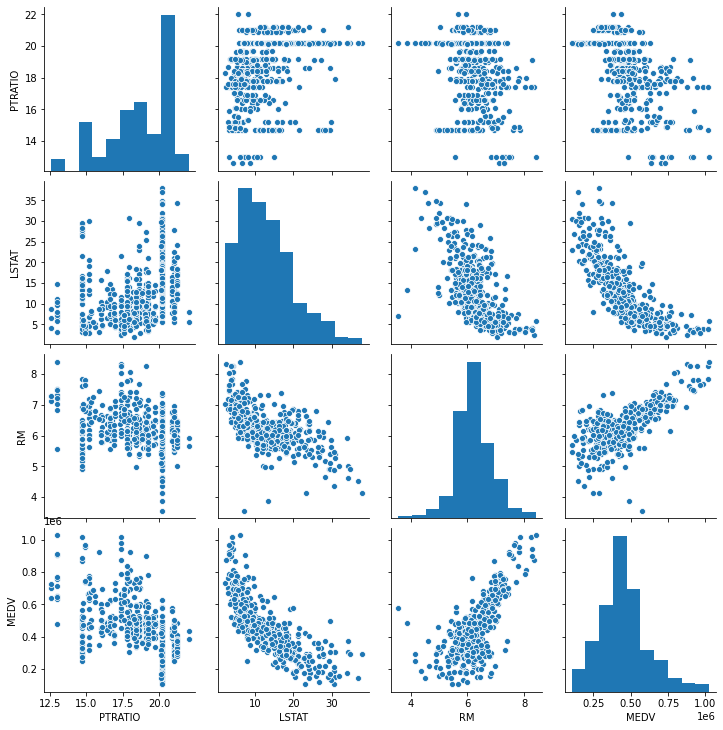

In [11]:



g=sns.pairplot(df[['PTRATIO','LSTAT','RM','MEDV']])

![](http://)График распределения величин. На пересечении - график совместных распределений. На диагонали -  гистограммы.

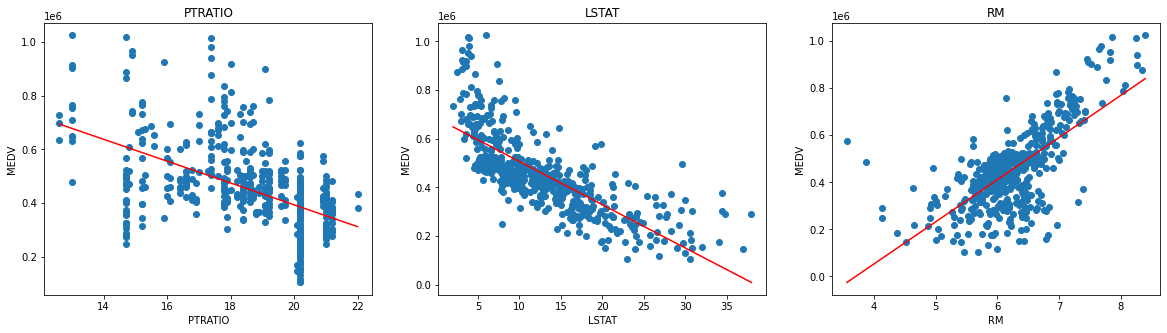

In [35]:
plt.figure(figsize=(20,5))
for i, col in enumerate(['PTRATIO','LSTAT','RM']):
    plt.subplot(1,3,i+1)
    x=df[col]
    y=df.MEDV
    plt.plot(x,y,'o')
    plt.plot(np.unique(x), np.poly1d(np.polyfit(x,y,1))(np.unique(x)),color='r')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('MEDV')

In [13]:
from sklearn.model_selection import train_test_split
y=df['MEDV']
x=df.drop('MEDV',axis=1)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=0)

In [15]:
from sklearn.model_selection import  cross_validate
from sklearn.model_selection import learning_curve, GridSearchCV
from sklearn import  linear_model, metrics
regr=linear_model.SGDRegressor(random_state=42)
regr.fit(x_train,y_train)
y_pred=regr.predict(x_test)

print(metrics.mean_absolute_error(y_test,y_pred))

1566245.3371754629


In [16]:
print(y_test[0:10].tolist())
print(list(map(lambda x:"{:2e}".format(x),y_pred[0:10])))

[417900.0, 632100.0, 281400.0, 577500.0, 474600.0, 359100.0, 247800.0, 474600.0, 449400.0, 411600.0]
['1.413092e+06', '3.189673e+06', '2.807602e+06', '-3.603775e+06', '1.359995e+06', '-2.135178e+06', '3.904773e+06', '1.612345e+05', '1.547058e+06', '-6.914119e+04']


In [36]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(x_train,y_train)
scaled_train_data=scaler.transform(x_train)
scaled_test_data=scaler.transform(x_test)

In [37]:
regr.fit(scaled_train_data,y_train)
y_scaled_pred=regr.predict(scaled_test_data)
print(metrics.mean_absolute_error(y_test,y_scaled_pred))

72682.8998734447


In [19]:
print(y_test.values[:5])
print(y_scaled_pred[:5])

[417900. 632100. 281400. 577500. 474600.]
[417809.14 687206.46 305067.95 397051.14 530468.86]


Создаем график, который называется residual polts

Text(0.5, 1.0, 'Prices vs Predicted prices: $Y_i$ vs $\\hat{Y}_i$')

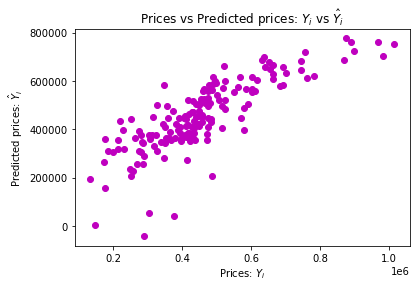

In [38]:
import matplotlib.pyplot as plt
y_pred=regr.predict(x_test)
plt.scatter(y_test,y_scaled_pred,color="m")
plt.xlabel("Prices: $Y_i$")
plt.ylabel("Predicted prices: $\hat{Y}_i$")
plt.title("Prices vs Predicted prices: $Y_i$ vs $\hat{Y}_i$")

In [21]:

from sklearn.pipeline import Pipeline

pipe=Pipeline(steps=[('scaling',scaler),('regression',regr)])
pipe.fit(x_train,y_train)
print(metrics.mean_absolute_error(y_test,pipe.predict(x_test)))

72682.8998734447


In [22]:
pipe.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'scaling', 'regression', 'scaling__copy', 'scaling__with_mean', 'scaling__with_std', 'regression__alpha', 'regression__average', 'regression__early_stopping', 'regression__epsilon', 'regression__eta0', 'regression__fit_intercept', 'regression__l1_ratio', 'regression__learning_rate', 'regression__loss', 'regression__max_iter', 'regression__n_iter_no_change', 'regression__penalty', 'regression__power_t', 'regression__random_state', 'regression__shuffle', 'regression__tol', 'regression__validation_fraction', 'regression__verbose', 'regression__warm_start'])

In [23]:
from sklearn.model_selection import GridSearchCV



parameters_grid={
    'regression__loss':['huber','squared_loss',],
    'regression__n_iter_no_change':[ 5,10,20],
    'regression__penalty':['l1','l2','none'],
    'regression__alpha':[0.0001,0.001,0.1],
}
grid_cv=GridSearchCV(pipe,parameters_grid,scoring='neg_mean_absolute_error',cv=4)

grid_cv.fit(x_train, y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:1211: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:1211: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:1211: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:1211: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/linea

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('scaling', StandardScaler()),
                                       ('regression',
                                        SGDRegressor(random_state=42))]),
             param_grid={'regression__alpha': [0.0001, 0.001, 0.1],
                         'regression__loss': ['huber', 'squared_loss'],
                         'regression__n_iter_no_change': [5, 10, 20],
                         'regression__penalty': ['l1', 'l2', 'none']},
             scoring='neg_mean_absolute_error')

In [24]:
print(-1*grid_cv.best_score_)
print(grid_cv.best_params_)

63079.2420074919
{'regression__alpha': 0.1, 'regression__loss': 'squared_loss', 'regression__n_iter_no_change': 5, 'regression__penalty': 'l2'}


Text(0.5, 1.0, 'Prices vs Predicted prices: $Y_i$ vs $\\hat{Y}_i$')

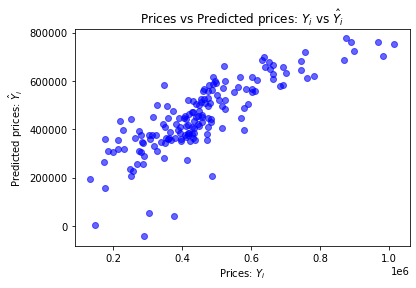

In [39]:
plt.scatter(y_test,pipe.predict(x_test),color="b",alpha=0.6)
plt.xlabel("Prices: $Y_i$")
plt.ylabel("Predicted prices: $\hat{Y}_i$")
plt.title("Prices vs Predicted prices: $Y_i$ vs $\hat{Y}_i$")

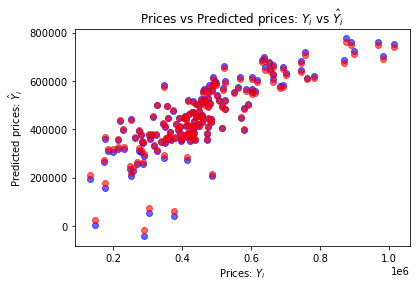

In [40]:
plt.scatter(y_test,pipe.predict(x_test),color="b",alpha=0.6)
plt.scatter(y_test,grid_cv.best_estimator_.predict(x_test),color="r",alpha=0.6)
plt.xlabel("Prices: $Y_i$")
plt.ylabel("Predicted prices: $\hat{Y}_i$")
plt.title("Prices vs Predicted prices: $Y_i$ vs $\hat{Y}_i$")
plt.show()

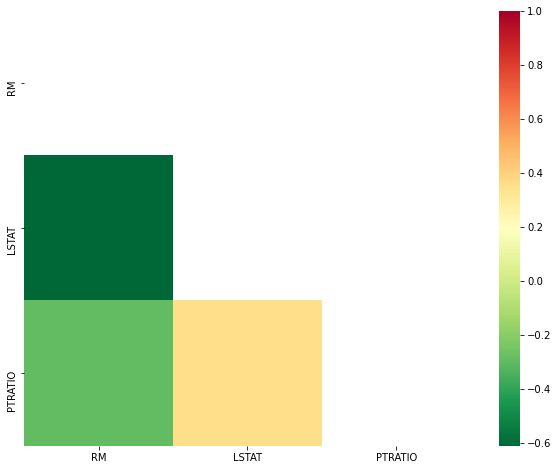

In [41]:
x_corr=x_train.corr(method="pearson")
mask=np.zeros_like(x_corr)
mask[np.triu_indices_from(mask)]=True
fig,ax=plt.subplots(figsize=(10,8))
fig=sns.heatmap(x_corr,cmap="RdYlGn_r",mask=mask)

plt.show()

In [42]:
x_train_dropped=x_train.drop('LSTAT',axis=1)
x_test_dropped=x_test.drop('LSTAT',axis=1)
grid_cv_drpd=grid_cv
grid_cv_drpd.fit(x_train_dropped,y_train)
print(-1*grid_cv_drpd.best_score_)
print(grid_cv_drpd.best_params_)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:1211: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:1211: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:1211: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:1211: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/linea

76208.42864780451
{'regression__alpha': 0.1, 'regression__loss': 'squared_loss', 'regression__n_iter_no_change': 20, 'regression__penalty': 'l1'}


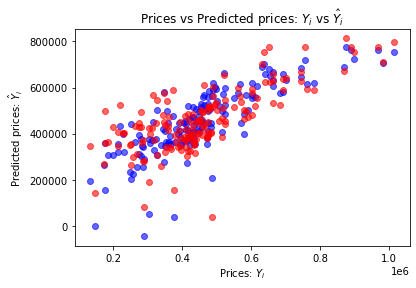

In [43]:
plt.scatter(y_test,pipe.predict(x_test),color="b",alpha=0.6)
plt.scatter(y_test,grid_cv.best_estimator_.predict(x_test_dropped),color="r",alpha=0.6)
plt.xlabel("Prices: $Y_i$")
plt.ylabel("Predicted prices: $\hat{Y}_i$")
plt.title("Prices vs Predicted prices: $Y_i$ vs $\hat{Y}_i$")
plt.show()

А теперь возьмем другую модель для обучения.

51791.833333333336


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:1211: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:1211: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:1211: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:1211: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/linea

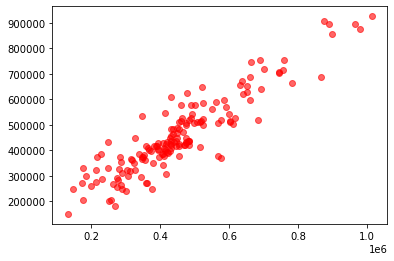

In [44]:
from sklearn.ensemble import RandomForestRegressor

rfr=RandomForestRegressor(random_state=42)
rfr.fit(x_train,y_train)
rf_predict=rfr.predict(x_test)
print(metrics.mean_absolute_error(y_test,rf_predict))

grid_cv=GridSearchCV(pipe,parameters_grid,scoring='neg_mean_absolute_error',cv=4)
grid_cv.fit(x_train,y_train)
plt.scatter(y_test,rf_predict,color="r",alpha=0.6)